# Dense Models for Tabular Prediction and California Housing Regression

This notebook applies TensorFlow dense models to tabular prediction. It begins with grade-based linear regression, binary classification, multiclass classification, and hidden-layer models, then develops a larger California Housing regression study covering scaling, linear depth, nonlinear hidden layers, width, and depth.


## Grade Prediction and Classification with TensorFlow

A small tabular grade dataset is used to progress from linear regression to logistic classification and hidden-layer networks.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
import tensorflow as tf
from keras.utils import plot_model
import time
from keras import activations
from keras.layers import *
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix

In [ ]:
"""
from pathlib import Path

data_candidates = [
    Path("data/grades.xlsx"),
    Path("../data/grades.xlsx"),
    Path("grades.xlsx"),
]
data_path = next((p for p in data_candidates if p.exists()), None)

if data_path is None:
    files.upload()
    data_path = Path("grades.xlsx")

df = pd.read_excel(data_path)
df
X = df.loc[:,['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df.loc[:,'Final Grade'].to_numpy()
"""

In [1]:
from google.colab import files
import pandas as pd

# Upload the dataset from your computer
uploaded = files.upload()

# Get the uploaded file name
filename = next(iter(uploaded))

# Load the dataset
df = pd.read_excel(filename)

# Display the dataset
display(df)

# Define input features and target
X = df[['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df['Final Grade'].to_numpy()

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Saving grades.xlsx to grades.xlsx


,Exam 1,Quiz 1,Lab 1,Final Grade,Letter
0,81.882163,69.717432,70.105509,74.682705,C
1,45.477935,82.650857,69.276236,60.253443,D
2,92.290039,55.665642,97.743709,74.759426,C
3,62.506001,101.596774,48.535491,85.601871,B
4,87.178208,91.897542,47.053463,92.676490,A
...,...,...,...,...,...
195,19.396038,44.062580,97.581982,22.991312,F
196,85.306084,60.628632,93.169521,70.927532,C
197,76.735407,77.861060,66.002489,76.841090,C
198,82.025008,48.726994,77.864993,64.220041,D


Input shape: (200, 3)
Target shape: (200,)


# Linear Regression

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

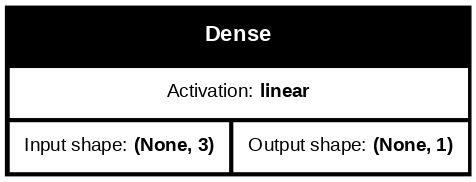

In [4]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  return model

model = linear_regression(X.shape[1], 1)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

In [5]:
model.fit(X, y, epochs = 40, batch_size = 40, verbose = 2)
y_pred = model.predict(X)
print('Mean squared error = {:5.3f}'.format(mean_squared_error(y_pred,y)))

Epoch 1/40
5/5 - 1s - 164ms/step - loss: 8524.2891
Epoch 2/40
5/5 - 0s - 11ms/step - loss: 519.4602
Epoch 3/40
5/5 - 0s - 9ms/step - loss: 2191.4480
Epoch 4/40
5/5 - 0s - 10ms/step - loss: 902.9163
Epoch 5/40
5/5 - 0s - 11ms/step - loss: 125.1387
Epoch 6/40
5/5 - 0s - 11ms/step - loss: 512.0444
Epoch 7/40
5/5 - 0s - 12ms/step - loss: 167.3701
Epoch 8/40
5/5 - 0s - 11ms/step - loss: 68.3023
Epoch 9/40
5/5 - 0s - 10ms/step - loss: 129.9337
Epoch 10/40
5/5 - 0s - 10ms/step - loss: 26.9753
Epoch 11/40
5/5 - 0s - 10ms/step - loss: 45.9872
Epoch 12/40
5/5 - 0s - 11ms/step - loss: 27.4133
Epoch 13/40
5/5 - 0s - 10ms/step - loss: 14.8984
Epoch 14/40
5/5 - 0s - 10ms/step - loss: 18.6837
Epoch 15/40
5/5 - 0s - 10ms/step - loss: 10.2309
Epoch 16/40
5/5 - 0s - 11ms/step - loss: 11.7218
Epoch 17/40
5/5 - 0s - 9ms/step - loss: 8.5535
Epoch 18/40
5/5 - 0s - 10ms/step - loss: 8.7375
Epoch 19/40
5/5 - 0s - 11ms/step - loss: 7.3301
Epoch 20/40
5/5 - 0s - 10ms/step - loss: 7.3478
Epoch 21/40
5/5 - 0s - 1

Epoch 1/40
5/5 - 1s - 196ms/step - loss: 17123.5996
Epoch 2/40
5/5 - 1s - 133ms/step - loss: 1704.7794
Epoch 3/40
5/5 - 0s - 10ms/step - loss: 2207.2659
Epoch 4/40
5/5 - 0s - 12ms/step - loss: 3038.9346
Epoch 5/40
5/5 - 0s - 29ms/step - loss: 1006.0195
Epoch 6/40
5/5 - 0s - 18ms/step - loss: 382.5538
Epoch 7/40
5/5 - 0s - 16ms/step - loss: 779.1068
Epoch 8/40
5/5 - 0s - 13ms/step - loss: 487.7596
Epoch 9/40
5/5 - 0s - 29ms/step - loss: 242.9611
Epoch 10/40
5/5 - 0s - 29ms/step - loss: 313.2749
Epoch 11/40
5/5 - 0s - 29ms/step - loss: 242.0999
Epoch 12/40
5/5 - 0s - 15ms/step - loss: 188.0986
Epoch 13/40
5/5 - 0s - 15ms/step - loss: 190.5614
Epoch 14/40
5/5 - 0s - 28ms/step - loss: 162.8000
Epoch 15/40
5/5 - 0s - 29ms/step - loss: 141.9810
Epoch 16/40
5/5 - 0s - 28ms/step - loss: 135.0399
Epoch 17/40
5/5 - 0s - 28ms/step - loss: 121.1703
Epoch 18/40
5/5 - 0s - 28ms/step - loss: 110.6970
Epoch 19/40
5/5 - 0s - 15ms/step - loss: 102.2736
Epoch 20/40
5/5 - 0s - 29ms/step - loss: 94.5582
Ep

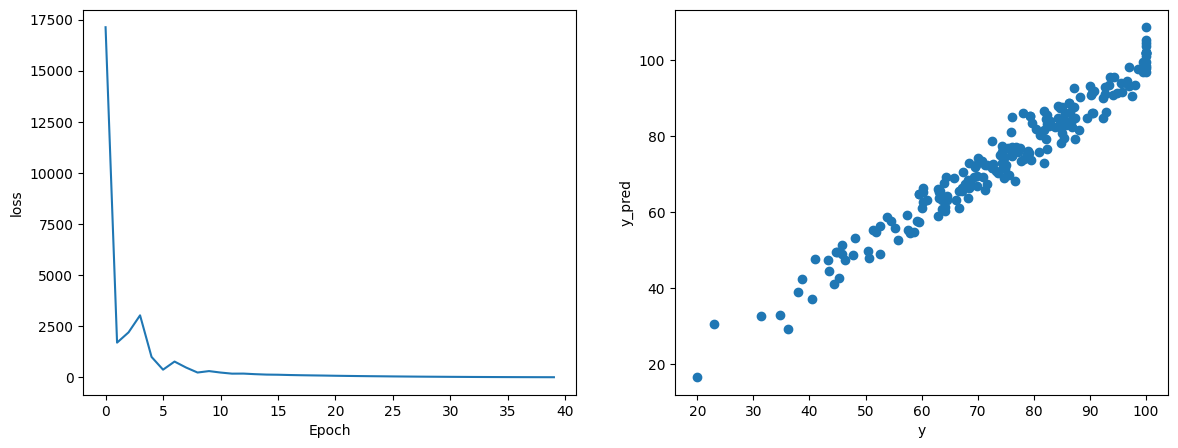

In [6]:
model = linear_regression(X.shape[1], 1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")
history = model.fit(X, y, epochs = 40, batch_size = 40, verbose = 2)
y_pred = model.predict(X)
print('Mean squared error = {:5.3f}'.format(mean_squared_error(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].scatter(y,y_pred)
ax[1].set_xlabel('y')
ax[1].set_ylabel('y_pred')
plt.show()

Usually, performance can be improved if we scale the input and output data to the 0 to 1 range, and the re-scale, if necessary.

Epoch 1/40
5/5 - 1s - 122ms/step - loss: 0.3693
Epoch 2/40
5/5 - 0s - 11ms/step - loss: 0.2512
Epoch 3/40
5/5 - 0s - 10ms/step - loss: 0.0780
Epoch 4/40
5/5 - 0s - 9ms/step - loss: 0.1034
Epoch 5/40
5/5 - 0s - 10ms/step - loss: 0.0428
Epoch 6/40
5/5 - 0s - 10ms/step - loss: 0.0483
Epoch 7/40
5/5 - 0s - 10ms/step - loss: 0.0244
Epoch 8/40
5/5 - 0s - 10ms/step - loss: 0.0262
Epoch 9/40
5/5 - 0s - 10ms/step - loss: 0.0173
Epoch 10/40
5/5 - 0s - 10ms/step - loss: 0.0170
Epoch 11/40
5/5 - 0s - 11ms/step - loss: 0.0120
Epoch 12/40
5/5 - 0s - 10ms/step - loss: 0.0105
Epoch 13/40
5/5 - 0s - 10ms/step - loss: 0.0082
Epoch 14/40
5/5 - 0s - 10ms/step - loss: 0.0067
Epoch 15/40
5/5 - 0s - 9ms/step - loss: 0.0060
Epoch 16/40
5/5 - 0s - 10ms/step - loss: 0.0047
Epoch 17/40
5/5 - 0s - 11ms/step - loss: 0.0038
Epoch 18/40
5/5 - 0s - 9ms/step - loss: 0.0033
Epoch 19/40
5/5 - 0s - 10ms/step - loss: 0.0026
Epoch 20/40
5/5 - 0s - 11ms/step - loss: 0.0023
Epoch 21/40
5/5 - 0s - 10ms/step - loss: 0.0020
Epo

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Mean squared error = 5.442


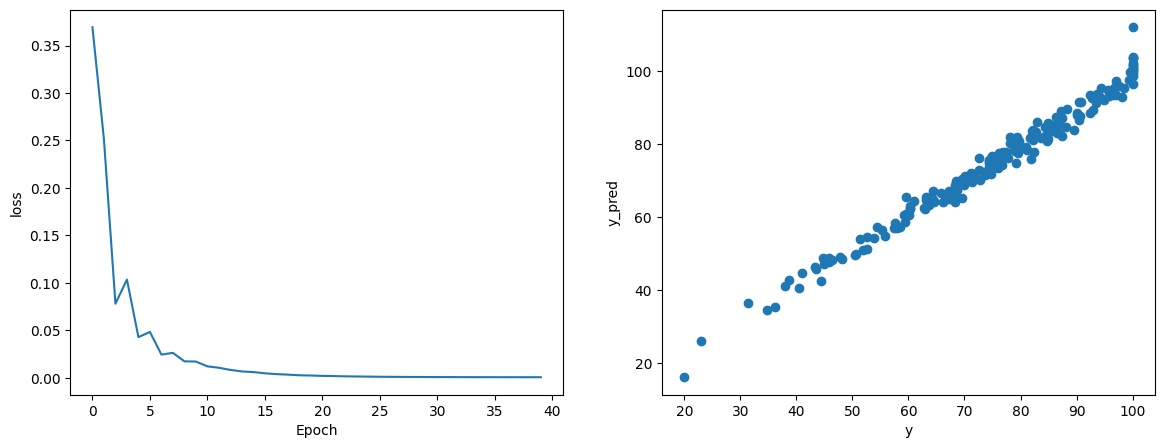

In [7]:
model = linear_regression(X.shape[1], 1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")
history = model.fit(X/100, y/100, epochs = 40, batch_size = 40, verbose = 2)
y_pred = model.predict(X/100)*100
print('Mean squared error = {:5.3f}'.format(mean_squared_error(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].scatter(y,y_pred)
ax[1].set_xlabel('y')
ax[1].set_ylabel('y_pred')
plt.show()

# Logistic Regression

## Binary classification

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

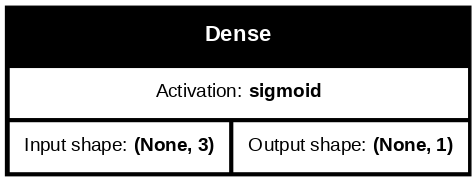

In [8]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs,activation='sigmoid'))
  return model

X = df.loc[:,['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df.loc[:,'Final Grade'].to_numpy()
y = np.int16(y>=70)

model = logistic_regression(X.shape[1], 1)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/100
10/10 - 1s - 78ms/step - accuracy: 0.6300 - loss: 0.6812
Epoch 2/100
10/10 - 0s - 8ms/step - accuracy: 0.6250 - loss: 0.6171
Epoch 3/100
10/10 - 0s - 6ms/step - accuracy: 0.6250 - loss: 0.5798
Epoch 4/100
10/10 - 0s - 6ms/step - accuracy: 0.6900 - loss: 0.5475
Epoch 5/100
10/10 - 0s - 6ms/step - accuracy: 0.7200 - loss: 0.5204
Epoch 6/100
10/10 - 0s - 7ms/step - accuracy: 0.7200 - loss: 0.4909
Epoch 7/100
10/10 - 0s - 6ms/step - accuracy: 0.8250 - loss: 0.4787
Epoch 8/100
10/10 - 0s - 6ms/step - accuracy: 0.7600 - loss: 0.4598
Epoch 9/100
10/10 - 0s - 7ms/step - accuracy: 0.8500 - loss: 0.4321
Epoch 10/100
10/10 - 0s - 6ms/step - accuracy: 0.8500 - loss: 0.4165
Epoch 11/100
10/10 - 0s - 6ms/step - accuracy: 0.8100 - loss: 0.4008
Epoch 12/100
10/10 - 0s - 6ms/step - accuracy: 0.8900 - loss: 0.3999
Epoch 13/100
10/10 - 0s - 6ms/step - accuracy: 0.7950 - loss: 0.3935
Epoch 14/100
10/10 - 0s - 6ms/step - accuracy: 0.8800 - loss: 0.3691
Epoch 15/100
10/10 - 0s - 6ms/step - accur

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Accuracy = 0.945


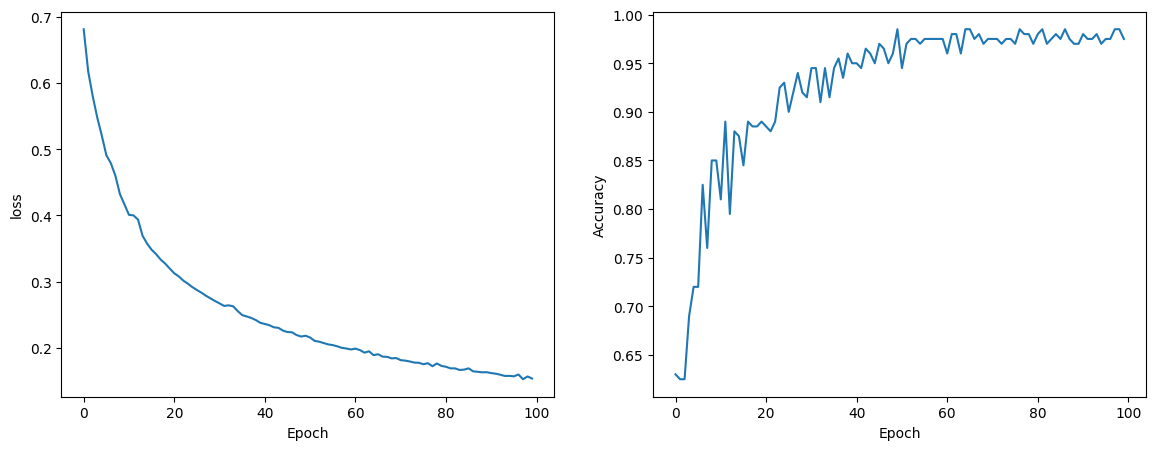

In [9]:
model = logistic_regression(X.shape[1], 1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X/100, y, epochs = 100, batch_size = 20, verbose = 2)
y_pred = np.int16(model.predict(X/100)>0.7)

print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].plot(history.history["accuracy"])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
plt.show()

## Multi-class classification

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 5)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

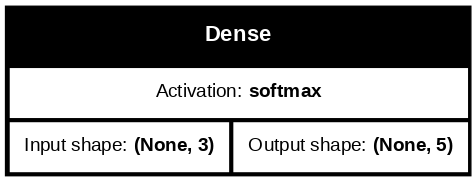

In [10]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

X = df.loc[:,['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = np.array(['FDCBA'.index(s) for s in df["Letter"]])
y_oh = tf.keras.utils.to_categorical(y,5)

model = logistic_regression(X.shape[1], 5)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/200
1/1 - 3s - 3s/step - accuracy: 0.1900 - loss: 1.7262
Epoch 2/200
1/1 - 0s - 124ms/step - accuracy: 0.1550 - loss: 1.6229
Epoch 3/200
1/1 - 0s - 127ms/step - accuracy: 0.2000 - loss: 1.6337
Epoch 4/200
1/1 - 0s - 119ms/step - accuracy: 0.2050 - loss: 1.6154
Epoch 5/200
1/1 - 0s - 172ms/step - accuracy: 0.3000 - loss: 1.5682
Epoch 6/200
1/1 - 0s - 129ms/step - accuracy: 0.4050 - loss: 1.5193
Epoch 7/200
1/1 - 0s - 109ms/step - accuracy: 0.4700 - loss: 1.4811
Epoch 8/200
1/1 - 0s - 134ms/step - accuracy: 0.5400 - loss: 1.4562
Epoch 9/200
1/1 - 0s - 92ms/step - accuracy: 0.4600 - loss: 1.4403
Epoch 10/200
1/1 - 0s - 176ms/step - accuracy: 0.4000 - loss: 1.4222
Epoch 11/200
1/1 - 0s - 219ms/step - accuracy: 0.4350 - loss: 1.3964
Epoch 12/200
1/1 - 0s - 81ms/step - accuracy: 0.5250 - loss: 1.3683
Epoch 13/200
1/1 - 0s - 258ms/step - accuracy: 0.5400 - loss: 1.3444
Epoch 14/200
1/1 - 0s - 233ms/step - accuracy: 0.5200 - loss: 1.3261
Epoch 15/200
1/1 - 0s - 250ms/step - accuracy: 0

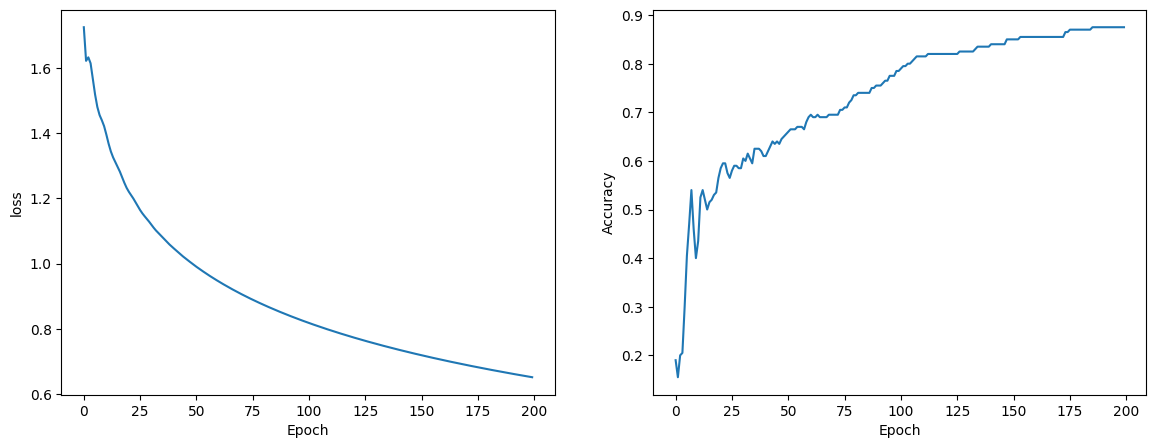

In [11]:
model = logistic_regression(X.shape[1], 5)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.2), loss="categorical_crossentropy", metrics=["accuracy"])
#model.compile(loss="categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X/100, y_oh, epochs = 200, batch_size = 200, verbose = 2)
y_pred = np.argmax(model.predict(X/100),axis=1)

print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].plot(history.history["accuracy"])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
plt.show()

## Adding a hidden layer

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (380.00 B)

 Trainable params: 95 (380.00 B)

 Non-trainable params: 0 (0.00 B)

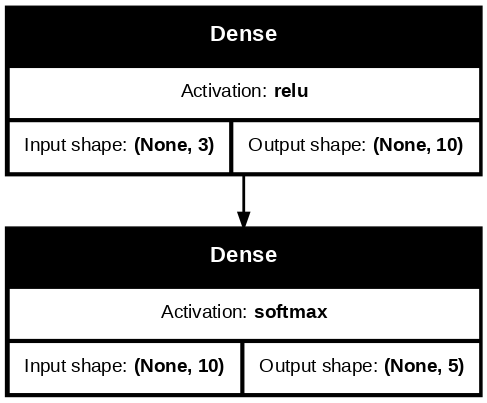

In [12]:
def three_layer_network(n_inputs, n_hidden, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_hidden,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

X = df.loc[:,['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = np.array(['FDCBA'.index(s) for s in df["Letter"]])
y_oh = tf.keras.utils.to_categorical(y,5)

model = three_layer_network(X.shape[1], 10, 5)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_activations=True,dpi=100)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Accuracy = 0.905


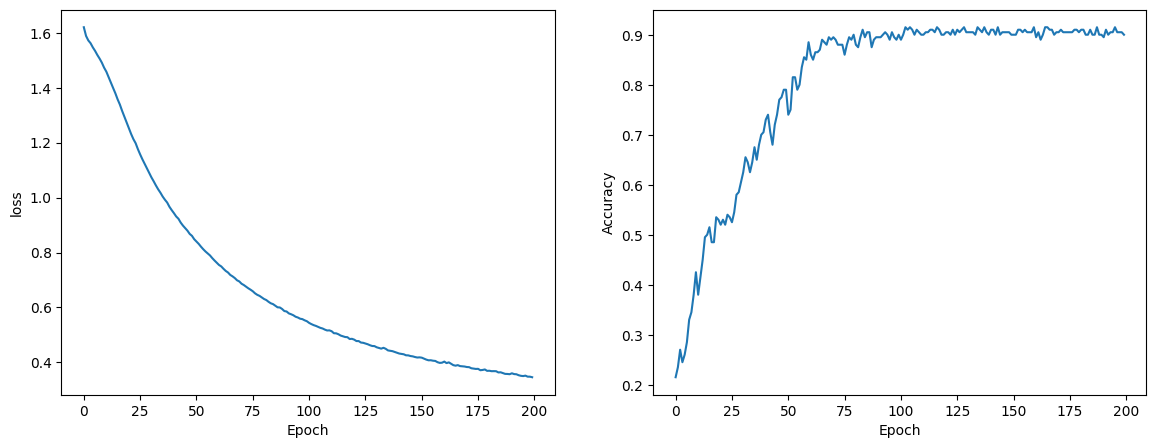

In [13]:
model = three_layer_network(X.shape[1],10, 5)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(X/100, y_oh, epochs = 200, batch_size = 40, verbose = 0)
y_pred = np.argmax(model.predict(X/100),axis=1)

print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].plot(history.history["accuracy"])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Accuracy = 0.910


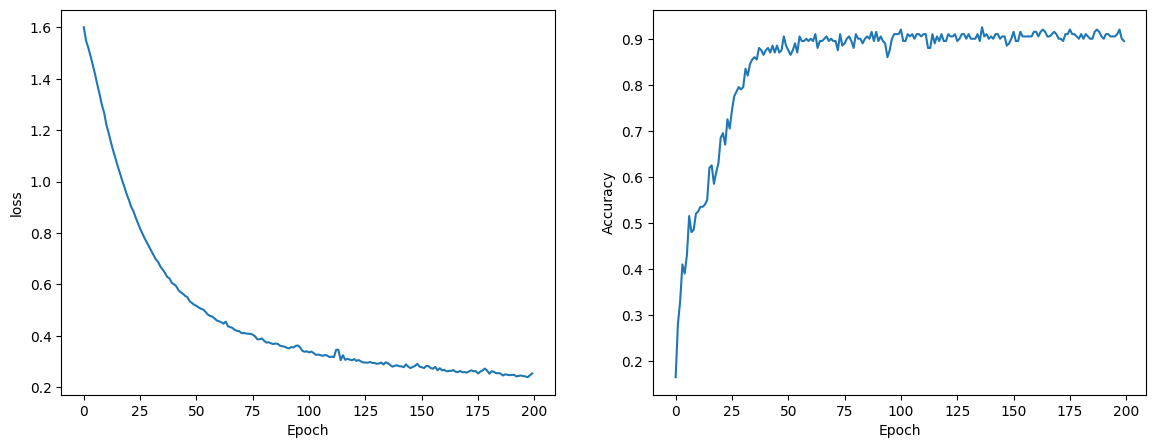

In [14]:
model = three_layer_network(X.shape[1],50, 5)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(X/100, y_oh, epochs = 200, batch_size = 40, verbose = 0)
y_pred = np.argmax(model.predict(X/100),axis=1)

print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].plot(history.history["accuracy"])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
plt.show()

## California Housing Dense Regression

California Housing is used to study preprocessing and architectural changes in dense regression models.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model

In [16]:
from sklearn.datasets import fetch_california_housing
dataset = fetch_california_housing()
x = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=5361)
print(X_train.shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))

(16512, 8)
Mean squared error = 0.54565
Mean absolute error =  0.54147


In [17]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=1)
  ax.plot(history.history['loss'],label = 'train')
  ax.plot(history.history['val_loss'],label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')

In [18]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 2s - 13ms/step - loss: 9098.8047 - val_loss: 57.6791
Epoch 2/30
166/166 - 1s - 5ms/step - loss: 47.7605 - val_loss: 37.8483
Epoch 3/30
166/166 - 1s - 4ms/step - loss: 32.8183 - val_loss: 26.0950
Epoch 4/30
166/166 - 1s - 3ms/step - loss: 21.7593 - val_loss: 17.1817
Epoch 5/30
166/166 - 1s - 3ms/step - loss: 13.9318 - val_loss: 10.9749
Epoch 6/30
166/166 - 1s - 3ms/step - loss: 8.6487 - val_loss: 6.8179
Epoch 7/30
166/166 - 1s - 3ms/step - loss: 5.3317 - val_loss: 4.2239
Epoch 8/30
166/166 - 1s - 3ms/step - loss: 3.3879 - val_loss: 2.8247
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 2.3163 - val_loss: 2.0945
Epoch 10/30
166/166 - 1s - 3ms/step - loss: 1.7542 - val_loss: 1.6851
Epoch 11/30
166/166 - 1s - 3ms/step - loss: 1.4496 - val_loss: 1.4448
Epoch 12/30
166/166 - 1s - 3ms/step - loss: 1.2659 - val_loss: 1.2880
Epoch 13/30
166/166 - 1s - 3ms/step - loss: 1.1383 - val_loss: 1.1666
Epoch 14/30
166/166 - 1s - 3ms/step - loss: 1.0426 - val_loss: 1.0378
Epoch 15/30
166/

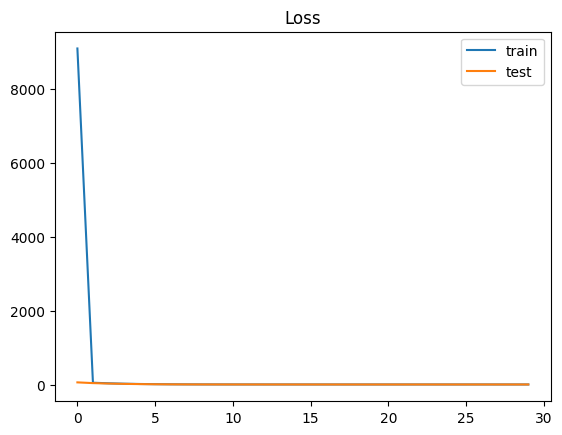

In [19]:
history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Scaling the data**

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
dataset = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=0.20, random_state=5361)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 1s - 9ms/step - loss: 2.8961 - val_loss: 1.2218
Epoch 2/30
166/166 - 1s - 3ms/step - loss: 1.1456 - val_loss: 1.0943
Epoch 3/30
166/166 - 1s - 3ms/step - loss: 1.0363 - val_loss: 0.9848
Epoch 4/30
166/166 - 1s - 3ms/step - loss: 0.9362 - val_loss: 0.8892
Epoch 5/30
166/166 - 1s - 3ms/step - loss: 0.8497 - val_loss: 0.8099
Epoch 6/30
166/166 - 1s - 3ms/step - loss: 0.7790 - val_loss: 0.7472
Epoch 7/30
166/166 - 1s - 3ms/step - loss: 0.7238 - val_loss: 0.6997
Epoch 8/30
166/166 - 1s - 3ms/step - loss: 0.6813 - val_loss: 0.6646
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 0.6508 - val_loss: 0.6405
Epoch 10/30
166/166 - 1s - 5ms/step - loss: 0.6289 - val_loss: 0.6249
Epoch 11/30
166/166 - 1s - 5ms/step - loss: 0.6140 - val_loss: 0.6127
Epoch 12/30
166/166 - 1s - 5ms/step - loss: 0.6035 - val_loss: 0.6053
Epoch 13/30
166/166 - 1s - 4ms/step - loss: 0.5963 - val_loss: 0.6002
Epoch 14/30
166/166 - 1s - 3ms/step - loss: 0.5911 - val_loss: 0.5969
Epoch 15/30
166/166 - 1s - 3m

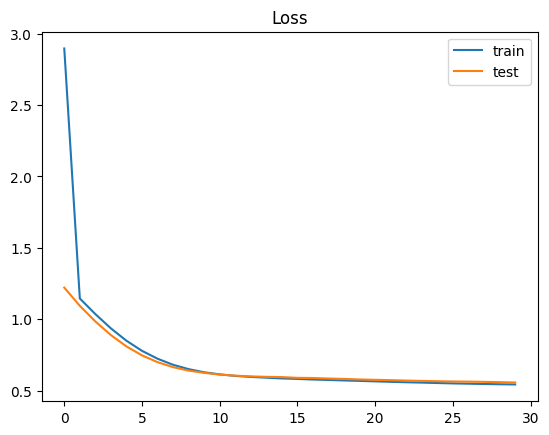

In [21]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Adding another linear layer**

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 3s - 16ms/step - loss: 1.2896 - val_loss: 0.7118
Epoch 2/30
166/166 - 1s - 3ms/step - loss: 0.6188 - val_loss: 0.6051
Epoch 3/30
166/166 - 1s - 3ms/step - loss: 0.5758 - val_loss: 0.5936
Epoch 4/30
166/166 - 1s - 3ms/step - loss: 0.5555 - val_loss: 0.5574
Epoch 5/30
166/166 - 1s - 3ms/step - loss: 0.5435 - val_loss: 0.5500
Epoch 6/30
166/166 - 1s - 3ms/step - loss: 0.5373 - val_loss: 0.5459
Epoch 7/30
166/166 - 1s - 3ms/step - loss: 0.5374 - val_loss: 0.5458
Epoch 8/30
166/166 - 1s - 3ms/step - loss: 0.5320 - val_loss: 0.5464
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 0.5302 - val_loss: 0.5509
Epoch 10/30
166/166 - 1s - 3ms/step - loss: 0.5362 - val_loss: 0.5503
Epoch 11/30
166/166 - 1s - 3ms/step - loss: 0.5295 - val_loss: 0.5470
Epoch 12/30
166/166 - 1s - 3ms/step - loss: 0.5311 - val_loss: 0.5429
Epoch 13/30
166/166 - 1s - 3ms/step - loss: 0.5320 - val_loss: 0.5479
Epoch 14/30
166/166 - 1s - 3ms/step - loss: 0.5311 - val_loss: 0.5513
Epoch 15/30
166/166 - 1s - 3

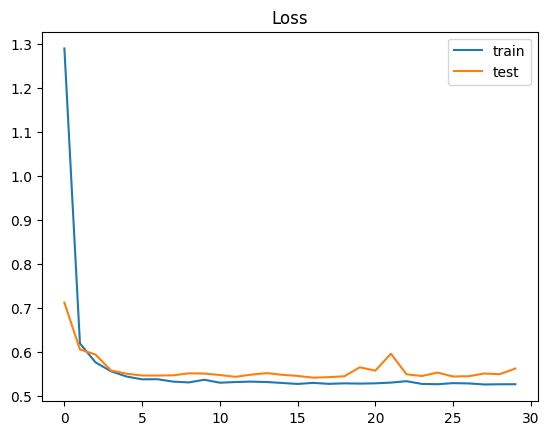

In [22]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(8),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Adding a non-linear layer**

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 2s - 12ms/step - loss: 1.3558 - val_loss: 0.7783
Epoch 2/30
166/166 - 1s - 3ms/step - loss: 0.6443 - val_loss: 0.6133
Epoch 3/30
166/166 - 1s - 3ms/step - loss: 0.5851 - val_loss: 0.5952
Epoch 4/30
166/166 - 1s - 5ms/step - loss: 0.5602 - val_loss: 0.5650
Epoch 5/30
166/166 - 1s - 5ms/step - loss: 0.5389 - val_loss: 0.5581
Epoch 6/30
166/166 - 1s - 5ms/step - loss: 0.5240 - val_loss: 0.5338
Epoch 7/30
166/166 - 1s - 5ms/step - loss: 0.5056 - val_loss: 0.5230
Epoch 8/30
166/166 - 1s - 4ms/step - loss: 0.4990 - val_loss: 0.5089
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 0.4905 - val_loss: 0.5073
Epoch 10/30
166/166 - 1s - 3ms/step - loss: 0.4880 - val_loss: 0.5203
Epoch 11/30
166/166 - 1s - 3ms/step - loss: 0.4810 - val_loss: 0.5261
Epoch 12/30
166/166 - 1s - 3ms/step - loss: 0.4811 - val_loss: 0.4951
Epoch 13/30
166/166 - 1s - 3ms/step - loss: 0.4771 - val_loss: 0.4997
Epoch 14/30
166/166 - 1s - 3ms/step - loss: 0.4759 - val_loss: 0.5017
Epoch 15/30
166/166 - 1s - 3

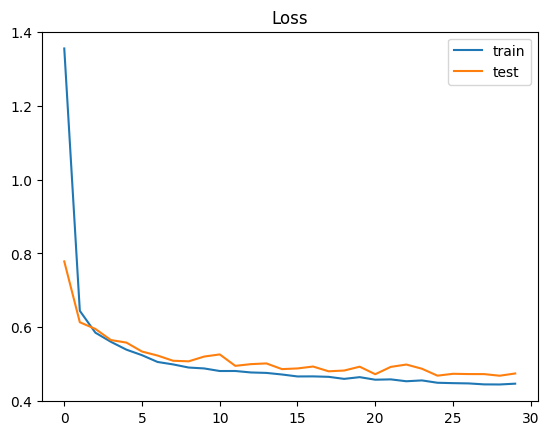

In [23]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Increasing the width**

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 2s - 13ms/step - loss: 1.0764 - val_loss: 0.6354
Epoch 2/30
166/166 - 1s - 3ms/step - loss: 0.5991 - val_loss: 0.5951
Epoch 3/30
166/166 - 1s - 3ms/step - loss: 0.5667 - val_loss: 0.5724
Epoch 4/30
166/166 - 1s - 3ms/step - loss: 0.5445 - val_loss: 0.5490
Epoch 5/30
166/166 - 1s - 3ms/step - loss: 0.5225 - val_loss: 0.5312
Epoch 6/30
166/166 - 1s - 3ms/step - loss: 0.5104 - val_loss: 0.5718
Epoch 7/30
166/166 - 1s - 3ms/step - loss: 0.5026 - val_loss: 0.5119
Epoch 8/30
166/166 - 1s - 3ms/step - loss: 0.4980 - val_loss: 0.5125
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 0.4920 - val_loss: 0.5067
Epoch 10/30
166/166 - 1s - 3ms/step - loss: 0.4918 - val_loss: 0.5129
Epoch 11/30
166/166 - 1s - 3ms/step - loss: 0.4966 - val_loss: 0.5029
Epoch 12/30
166/166 - 1s - 5ms/step - loss: 0.4879 - val_loss: 0.5019
Epoch 13/30
166/166 - 1s - 6ms/step - loss: 0.4826 - val_loss: 0.5066
Epoch 14/30
166/166 - 1s - 6ms/step - loss: 0.4842 - val_loss: 0.5002
Epoch 15/30
166/166 - 1s - 3

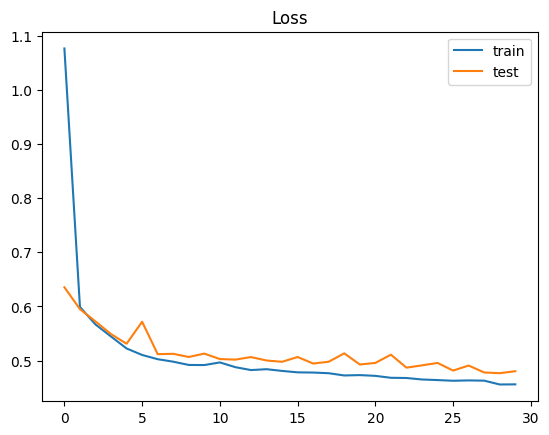

In [24]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Increasing the depth**

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153 (612.00 B)

 Trainable params: 153 (612.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 3s - 20ms/step - loss: 1.3326 - val_loss: 0.6307
Epoch 2/30
166/166 - 1s - 3ms/step - loss: 0.5917 - val_loss: 0.5634
Epoch 3/30
166/166 - 1s - 3ms/step - loss: 0.5336 - val_loss: 0.5239
Epoch 4/30
166/166 - 1s - 3ms/step - loss: 0.5035 - val_loss: 0.5017
Epoch 5/30
166/166 - 1s - 3ms/step - loss: 0.4842 - val_loss: 0.5122
Epoch 6/30
166/166 - 1s - 3ms/step - loss: 0.4758 - val_loss: 0.4893
Epoch 7/30
166/166 - 1s - 3ms/step - loss: 0.4711 - val_loss: 0.4938
Epoch 8/30
166/166 - 1s - 3ms/step - loss: 0.4646 - val_loss: 0.5432
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 0.4640 - val_loss: 0.4935
Epoch 10/30
166/166 - 1s - 3ms/step - loss: 0.4528 - val_loss: 0.4713
Epoch 11/30
166/166 - 1s - 3ms/step - loss: 0.4512 - val_loss: 0.4933
Epoch 12/30
166/166 - 1s - 3ms/step - loss: 0.4481 - val_loss: 0.4728
Epoch 13/30
166/166 - 1s - 3ms/step - loss: 0.4442 - val_loss: 0.4685
Epoch 14/30
166/166 - 1s - 3ms/step - loss: 0.4416 - val_loss: 0.4552
Epoch 15/30
166/166 - 1s - 3

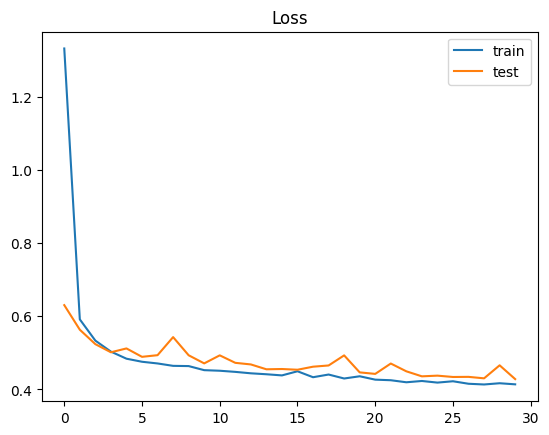

In [25]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 3s - 17ms/step - loss: 0.7833 - val_loss: 0.5549
Epoch 2/30
166/166 - 1s - 3ms/step - loss: 0.5307 - val_loss: 0.5351
Epoch 3/30
166/166 - 1s - 3ms/step - loss: 0.4891 - val_loss: 0.4748
Epoch 4/30
166/166 - 1s - 3ms/step - loss: 0.4564 - val_loss: 0.4598
Epoch 5/30
166/166 - 1s - 4ms/step - loss: 0.4440 - val_loss: 0.4650
Epoch 6/30
166/166 - 1s - 6ms/step - loss: 0.4431 - val_loss: 0.4630
Epoch 7/30
166/166 - 1s - 5ms/step - loss: 0.4347 - val_loss: 0.4281
Epoch 8/30
166/166 - 1s - 6ms/step - loss: 0.4224 - val_loss: 0.4513
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 0.4115 - val_loss: 0.4308
Epoch 10/30
166/166 - 1s - 3ms/step - loss: 0.3984 - val_loss: 0.4833
Epoch 11/30
166/166 - 1s - 3ms/step - loss: 0.4017 - val_loss: 0.4251
Epoch 12/30
166/166 - 1s - 3ms/step - loss: 0.3987 - val_loss: 0.4355
Epoch 13/30
166/166 - 1s - 3ms/step - loss: 0.4008 - val_loss: 0.4306
Epoch 14/30
166/166 - 1s - 3ms/step - loss: 0.3761 - val_loss: 0.3820
Epoch 15/30
166/166 - 1s - 3

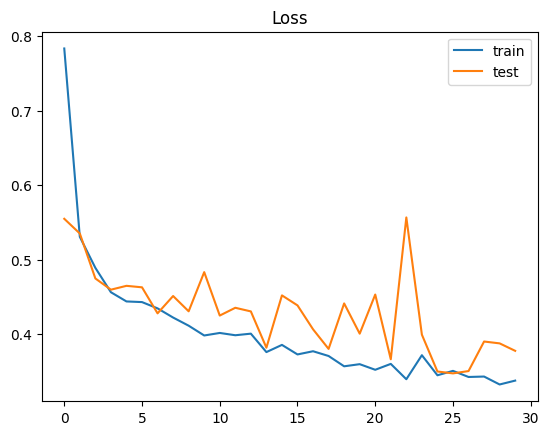

In [26]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,353 (267.00 KB)

 Trainable params: 68,353 (267.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
83/83 - 3s - 33ms/step - loss: 0.7892 - val_loss: 0.6083
Epoch 2/60
83/83 - 0s - 4ms/step - loss: 0.5424 - val_loss: 0.5063
Epoch 3/60
83/83 - 0s - 4ms/step - loss: 0.4791 - val_loss: 0.5009
Epoch 4/60
83/83 - 0s - 3ms/step - loss: 0.4966 - val_loss: 0.4745
Epoch 5/60
83/83 - 0s - 4ms/step - loss: 0.4398 - val_loss: 0.4387
Epoch 6/60
83/83 - 0s - 4ms/step - loss: 0.4314 - val_loss: 0.4500
Epoch 7/60
83/83 - 0s - 4ms/step - loss: 0.4262 - val_loss: 0.4312
Epoch 8/60
83/83 - 0s - 4ms/step - loss: 0.4343 - val_loss: 0.4374
Epoch 9/60
83/83 - 0s - 4ms/step - loss: 0.4032 - val_loss: 0.4467
Epoch 10/60
83/83 - 0s - 4ms/step - loss: 0.4073 - val_loss: 0.4649
Epoch 11/60
83/83 - 0s - 4ms/step - loss: 0.3960 - val_loss: 0.4372
Epoch 12/60
83/83 - 0s - 4ms/step - loss: 0.4025 - val_loss: 0.4288
Epoch 13/60
83/83 - 0s - 4ms/step - loss: 0.3855 - val_loss: 0.3941
Epoch 14/60
83/83 - 0s - 4ms/step - loss: 0.4017 - val_loss: 0.4366
Epoch 15/60
83/83 - 0s - 4ms/step - loss: 0.3756 - val_l

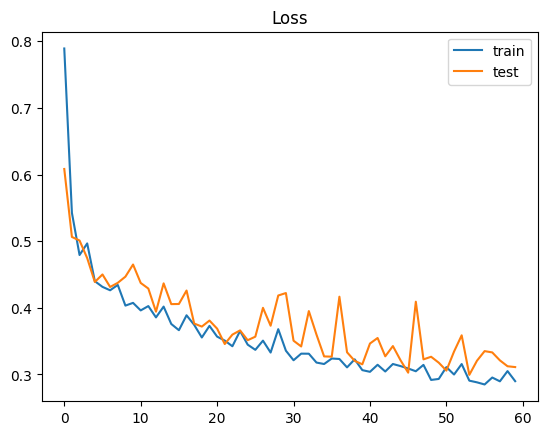

In [27]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 60,
    batch_size = 200,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,353 (267.00 KB)

 Trainable params: 68,353 (267.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
83/83 - 2s - 28ms/step - loss: 0.6130 - val_loss: 0.5243
Epoch 2/60
83/83 - 0s - 4ms/step - loss: 0.5053 - val_loss: 0.5071
Epoch 3/60
83/83 - 0s - 4ms/step - loss: 0.4885 - val_loss: 0.5170
Epoch 4/60
83/83 - 0s - 4ms/step - loss: 0.4663 - val_loss: 0.4632
Epoch 5/60
83/83 - 0s - 4ms/step - loss: 0.4563 - val_loss: 0.4542
Epoch 6/60
83/83 - 0s - 4ms/step - loss: 0.4592 - val_loss: 0.4500
Epoch 7/60
83/83 - 0s - 4ms/step - loss: 0.4533 - val_loss: 0.4472
Epoch 8/60
83/83 - 0s - 4ms/step - loss: 0.4364 - val_loss: 0.4401
Epoch 9/60
83/83 - 0s - 4ms/step - loss: 0.4468 - val_loss: 0.4455
Epoch 10/60
83/83 - 0s - 4ms/step - loss: 0.4432 - val_loss: 0.4358
Epoch 11/60
83/83 - 0s - 4ms/step - loss: 0.4288 - val_loss: 0.4368
Epoch 12/60
83/83 - 0s - 4ms/step - loss: 0.4245 - val_loss: 0.4183
Epoch 13/60
83/83 - 0s - 4ms/step - loss: 0.4331 - val_loss: 0.4327
Epoch 14/60
83/83 - 0s - 4ms/step - loss: 0.4253 - val_loss: 0.4203
Epoch 15/60
83/83 - 0s - 4ms/step - loss: 0.4205 - val_l

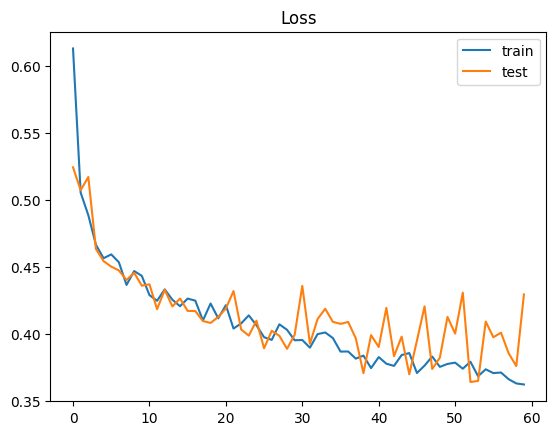

In [28]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mae")

history = model.fit(
    X_train, y_train,
    epochs = 60,
    batch_size = 200,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)